In [32]:
## importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.gam.api import GLMGam, BSplines
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [33]:
## reading data
df = pd.read_csv('/Users/zaiba/Documents/Biodiversity-Predictors/data/processed/marine_data_cleaned.csv')

## 
features = ['abs_latitude', 'temp_proxy', 'mean_depth']
target = 'species_richness'

df_gam = df[features + [target]].dropna()
X = df_gam[features].to_numpy(float)
y = df_gam[target].to_numpy(float)

##splitting the data into training and testing sets, and standardizing the features
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=17)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

In [34]:
knot_kwds = []
for j in range(X_tr_s.shape[1]):
    # use global min/max across train AND test
    lo = min(X_tr_s[:, j].min(), X_te_s[:, j].min())
    hi = max(X_tr_s[:, j].max(), X_te_s[:, j].max())
    pad = 0.1 * (hi - lo + 1e-12)
    knot_kwds.append({'lower_bound': lo - pad, 'upper_bound': hi + pad})

bs = BSplines(X_tr_s, df=[6]*3, degree=[3]*3, knot_kwds=knot_kwds)

exog_tr = np.ones((len(X_tr_s), 1))
exog_te = np.ones((len(X_te_s), 1))

gam = GLMGam(y_tr, exog=exog_tr, smoother=bs,
             family=sm.families.Gaussian())
gam_res = gam.fit()

In [35]:
yhat = gam_res.predict(exog=exog_te, exog_smooth=X_te_s)
rmse = np.sqrt(mean_squared_error(y_te, yhat))

print(f"RMSE:              {rmse:.3f}")
print(f"AIC:               {gam_res.aic:.3f}")
print(f"Deviance Explained:{1 - gam_res.deviance / gam_res.null_deviance:.3f}")


RMSE:              27.048
AIC:               12298.947
Deviance Explained:0.213


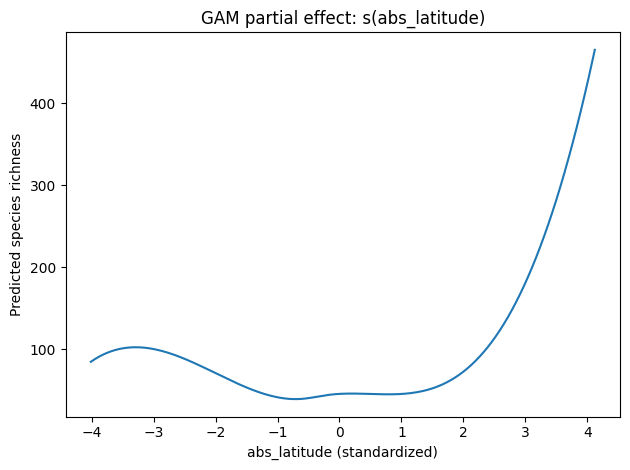

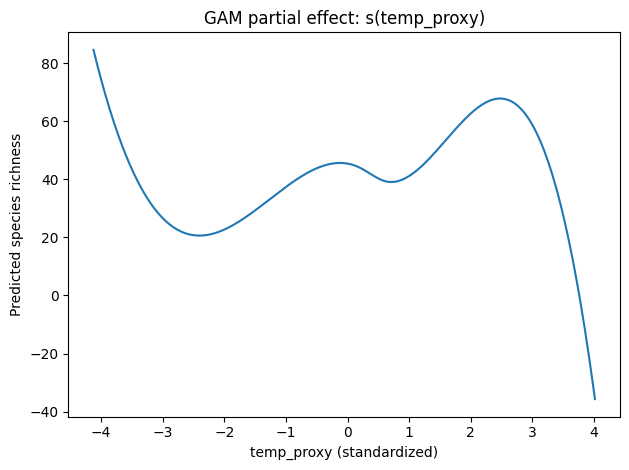

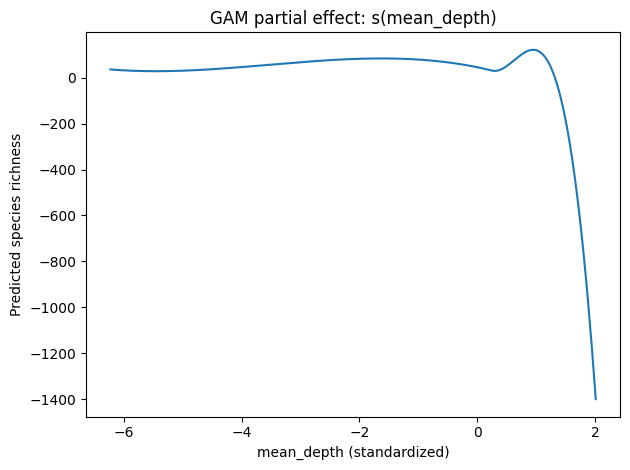

In [36]:
for j, col in enumerate(features):
    knots_j = bs.smoothers[j].knots
    lo_j, hi_j = np.min(knots_j), np.max(knots_j)
    xg = np.linspace(lo_j, hi_j, 250)

    X_grid = np.zeros((len(xg), len(features)))
    X_grid[:, j] = xg
    exog_grid = np.ones((len(xg), 1))

    y_grid = gam_res.predict(exog=exog_grid, exog_smooth=X_grid)

    plt.figure()
    plt.plot(xg, y_grid)
    plt.xlabel(f'{col} (standardized)')
    plt.ylabel('Predicted species richness')
    plt.title(f'GAM partial effect: s({col})')
    plt.tight_layout()
    plt.show()